# Imoprts

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import glob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
import tensorflow as tf
from keras import layers
from time import perf_counter
import seaborn as sns
from sklearn.metrics import accuracy_score

# Install the data and pre-processing

In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!echo '{"username":"ddooaa","key":"ad34e26f23cde872895a312699b13bbc"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rashwan/arabic-chars-mnist
!unzip arabic-chars-mnist.zip

mkdir: cannot create directory ‘/root/.kaggle’: File exists
arabic-chars-mnist.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  arabic-chars-mnist.zip
replace test/ain1042.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test/ain1043.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


(32, 32, 3)
(32, 32, 3)
Unique labels for training images: ['waw' 'thal' 'reh' 'dad' 'zain' 'alef' 'zah' 'seen' 'feh' 'heh' 'qaf'
 'teh' 'yeh' 'ghain' 'ain' 'kaf' 'noon' 'tah' 'jeem' 'meem' 'dal' 'lam'
 'theh' 'sheen' 'hah' 'sad' 'khah' 'beh']
Unique labels for test images: ['tah' 'dad' 'zain' 'waw' 'dal' 'zah' 'qaf' 'meem' 'sad' 'jeem' 'teh'
 'ghain' 'thal' 'kaf' 'alef' 'ain' 'theh' 'heh' 'beh' 'noon' 'sheen' 'reh'
 'yeh' 'khah' 'seen' 'feh' 'lam' 'hah']


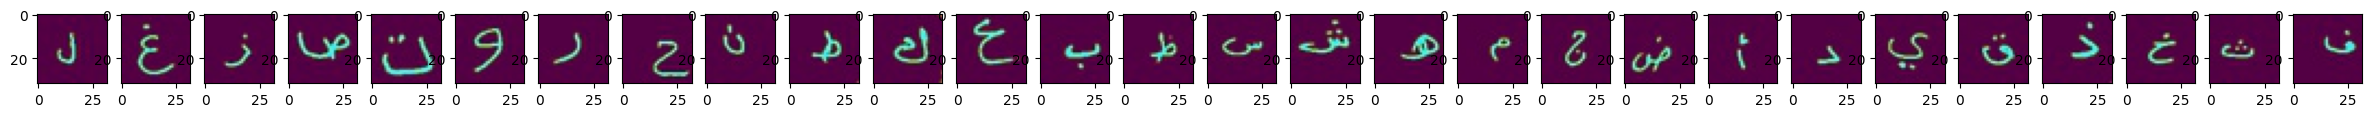

In [ ]:
TRAIN_DIR = '/content/train'
TEST_DIR = '/content/test'
train_images = [os.path.join(TRAIN_DIR, i) for i in os.listdir(TRAIN_DIR)]
test_images = [os.path.join(TEST_DIR, i) for i in os.listdir(TEST_DIR)]

# Function to extract the labels from the image path
def get_labels(fname):
    parts = re.split('/', fname)[-1]
    part = re.split(r'(\d+)', parts)
    return part[0]

# Storing path and label of training images in a list
path_and_label_train = [[filename, get_labels(filename)] for filename in glob.glob(os.path.join(TRAIN_DIR, '*.jpg'))]

# Converting the list to a DataFrame
df_train = pd.DataFrame(path_and_label_train, columns=['path', 'label'])

# Storing path of the test images as a DataFrame
df_test = pd.DataFrame(test_images, columns=['path'])
df_test['label'] = 0

# Displaying a subset of training images from each class
fig, ax = plt.subplots(1, 28, figsize=(30, 12))
for i, name in enumerate(set(df_train['label'])):
    sample = df_train[df_train['label'] == name].sample(1)
    image_path = sample['path'].item()
    X = cv2.imread(image_path)
    ax[i].imshow(X)

# Function to read an image using OpenCV
def read_image(path):
    img = cv2.imread(path)
    return img

# Reading and storing training images
x_train = np.array([read_image(path) for path in df_train['path']])

# Reading and storing test images
x_test = np.array([read_image(path) for path in df_test['path']])

print(x_train[10].shape)
print(x_test[40].shape)


# Converting labels from string to integer using LabelEncoder
lb = LabelEncoder()
y_train = lb.fit_transform(df_train['label'])

# Converting labels to categorical format
y_train = to_categorical(y_train, num_classes=28)

# Printing all the unique labels for training images
unique_labels_train = df_train['label'].unique()
print("Unique labels for training images:", unique_labels_train)

# Storing path and label of test images in a list
path_and_label_test = [[filename, get_labels(filename)] for filename in glob.glob(os.path.join(TEST_DIR, '*.jpg'))]

# Converting the list to a DataFrame
df_test = pd.DataFrame(path_and_label_test, columns=['path', 'label'])

# Converting labels from string to integer using LabelEncoder
y_test = lb.transform(df_test['label'])

# Converting labels to categorical format
y_test = to_categorical(y_test, num_classes=28)

# Printing all the unique labels for test images
unique_labels_test = df_test['label'].unique()
print("Unique labels for test images:", unique_labels_test)

# The Model

**The Orginal**

In [ ]:
# Splitting the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Define the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=x_train[0].shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(28, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
#Print a summary of the model
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 4, 4, 128)         73856     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 2, 2, 128)        

Epoch 1/20
336/336 [==============================] - 33s 94ms/step - loss: 3.3621 - accuracy: 0.1065 - val_loss: 2.4489 - val_accuracy: 0.2958
Epoch 2/20
336/336 [==============================] - 22s 66ms/step - loss: 2.1800 - accuracy: 0.3044 - val_loss: 1.3766 - val_accuracy: 0.5283
Epoch 3/20
336/336 [==============================] - 16s 47ms/step - loss: 1.4826 - accuracy: 0.4906 - val_loss: 0.7752 - val_accuracy: 0.7403
Epoch 4/20
336/336 [==============================] - 16s 46ms/step - loss: 1.0922 - accuracy: 0.6168 - val_loss: 0.5821 - val_accuracy: 0.8099
Epoch 5/20
336/336 [==============================] - 15s 46ms/step - loss: 0.8513 - accuracy: 0.7099 - val_loss: 0.4630 - val_accuracy: 0.8441
Epoch 6/20
336/336 [==============================] - 16s 47ms/step - loss: 0.6864 - accuracy: 0.7667 - val_loss: 0.4385 - val_accuracy: 0.8557
Epoch 7/20
336/336 [==============================] - 15s 46ms/step - loss: 0.5601 - accuracy: 0.8105 - val_loss: 0.4221 - val_accuracy:

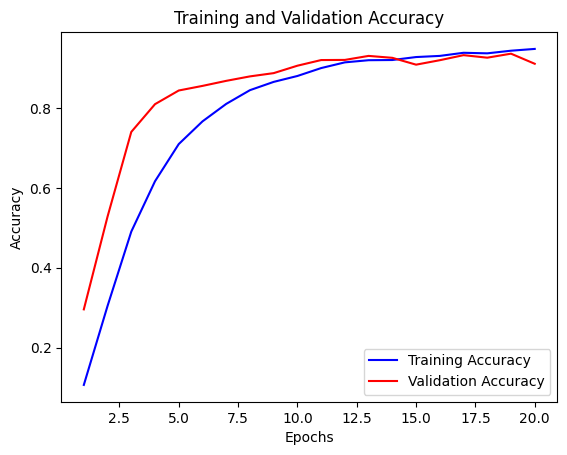

In [ ]:
# Train the model and store the training history
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=20, batch_size=32)

# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Make predictions on the test data
predictions = model.predict(x_test)

# Convert predictions to categorical format
predicted_labels = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(np.argmax(y_test, axis=1), predicted_labels)

# Print the predicted labels for the test images
predicted_labels = lb.inverse_transform(np.argmax(predictions, axis=1))
print("Predicted labels for test images:", predicted_labels)

# Print the accuracy
print("Accuracy:", accuracy)

105/105 [==============================] - 1s 11ms/step
Predicted labels for test images: ['tah' 'dad' 'zain' ... 'tah' 'tah' 'ghain']
Accuracy: 0.9125


# Changeing The Number Of The Filter

In [ ]:

# Splitting the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Define the CNN model with modified hyperparameters
model = Sequential()
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=x_train[0].shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(28, activation='softmax'))

# Compile the model with modified hyperparameters
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/20
336/336 [==============================] - 47s 134ms/step - loss: 3.1942 - accuracy: 0.1830 - val_loss: 1.7145 - val_accuracy: 0.4833
Epoch 2/20
336/336 [==============================] - 46s 137ms/step - loss: 1.5792 - accuracy: 0.4851 - val_loss: 0.9013 - val_accuracy: 0.6979
Epoch 3/20
336/336 [==============================] - 46s 138ms/step - loss: 0.9401 - accuracy: 0.6849 - val_loss: 0.5724 - val_accuracy: 0.8114
Epoch 4/20
336/336 [==============================] - 46s 138ms/step - loss: 0.6367 - accuracy: 0.7852 - val_loss: 0.3638 - val_accuracy: 0.8821
Epoch 5/20
336/336 [==============================] - 48s 142ms/step - loss: 0.4525 - accuracy: 0.8462 - val_loss: 0.2924 - val_accuracy: 0.9148
Epoch 6/20
336/336 [==============================] - 47s 139ms/step - loss: 0.3436 - accuracy: 0.8871 - val_loss: 0.2419 - val_accuracy: 0.9196
Epoch 7/20
336/336 [==============================] - 46s 138ms/step - loss: 0.2709 - accuracy: 0.9089 - val_loss: 0.2579 - val_ac

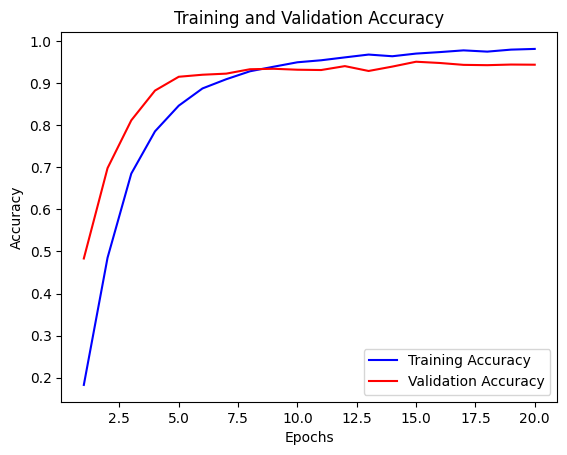

In [ ]:
# Train the model and store the training history
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=20, batch_size=32)

# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
# Make predictions on the test data
predictions = model.predict(x_test)

# Convert predictions to categorical format
predicted_labels = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(np.argmax(y_test, axis=1), predicted_labels)

# Print the predicted labels for the test images
predicted_labels = lb.inverse_transform(np.argmax(predictions, axis=1))
print("Predicted labels for test images:", predicted_labels)

# Print the accuracy
print("Accuracy:", accuracy)

105/105 [==============================] - 0s 2ms/step
Predicted labels for test images: ['lam' 'noon' 'beh' ... 'kaf' 'heh' 'heh']
Accuracy: 0.9086309523809524


# Changeing The Number Of The Epoch

## Changeing The Number Of The Epoch = 10

In [ ]:
# Splitting the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Define the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=x_train[0].shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(28, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
#Print a summary of the model
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 128)         0

Epoch 1/10
336/336 [==============================] - 22s 62ms/step - loss: 3.5471 - accuracy: 0.1070 - val_loss: 2.2535 - val_accuracy: 0.3408
Epoch 2/10
336/336 [==============================] - 18s 55ms/step - loss: 2.1152 - accuracy: 0.3374 - val_loss: 1.2902 - val_accuracy: 0.5673
Epoch 3/10
336/336 [==============================] - 17s 50ms/step - loss: 1.3954 - accuracy: 0.5150 - val_loss: 0.7796 - val_accuracy: 0.7195
Epoch 4/10
336/336 [==============================] - 17s 52ms/step - loss: 1.0017 - accuracy: 0.6473 - val_loss: 0.5586 - val_accuracy: 0.8144
Epoch 5/10
336/336 [==============================] - 17s 51ms/step - loss: 0.7936 - accuracy: 0.7194 - val_loss: 0.5481 - val_accuracy: 0.8129
Epoch 6/10
336/336 [==============================] - 18s 53ms/step - loss: 0.6235 - accuracy: 0.7844 - val_loss: 0.4145 - val_accuracy: 0.8705
Epoch 7/10
336/336 [==============================] - 17s 51ms/step - loss: 0.5026 - accuracy: 0.8251 - val_loss: 0.2958 - val_accuracy:

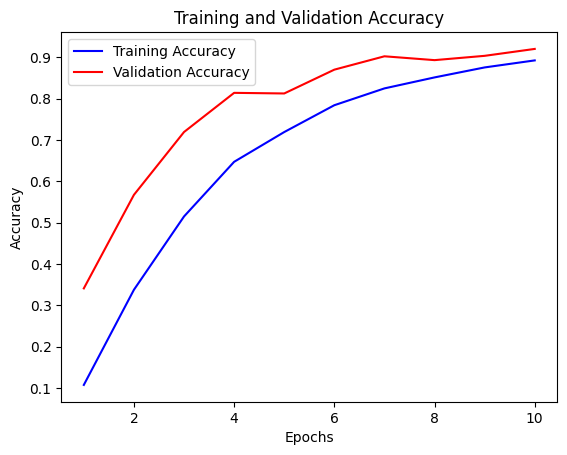

In [ ]:
# Train the model and store the training history
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10, batch_size=32)

# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
# Make predictions on the test data
predictions = model.predict(x_test)

# Convert predictions to categorical format
predicted_labels = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(np.argmax(y_test, axis=1), predicted_labels)

# Print the predicted labels for the test images
predicted_labels = lb.inverse_transform(np.argmax(predictions, axis=1))
print("Predicted labels for test images:", predicted_labels)

# Print the accuracy
print("Accuracy:", accuracy)

105/105 [==============================] - 3s 23ms/step
Predicted labels for test images: ['zain' 'zah' 'jeem' ... 'sad' 'sheen' 'kaf']
Accuracy: 0.9157738095238095


## Changeing The Number Of The Epoch = 15

In [ ]:
# Splitting the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Define the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=x_train[0].shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(28, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
#Print a summary of the model
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 128)         73856     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 2, 2, 128)        

Epoch 1/15
336/336 [==============================] - 19s 52ms/step - loss: 3.4449 - accuracy: 0.0971 - val_loss: 2.5463 - val_accuracy: 0.2604
Epoch 2/15
336/336 [==============================] - 17s 49ms/step - loss: 2.2279 - accuracy: 0.2822 - val_loss: 1.2838 - val_accuracy: 0.5517
Epoch 3/15
336/336 [==============================] - 17s 49ms/step - loss: 1.5115 - accuracy: 0.4796 - val_loss: 0.8270 - val_accuracy: 0.7206
Epoch 4/15
336/336 [==============================] - 17s 51ms/step - loss: 1.1295 - accuracy: 0.5912 - val_loss: 0.6117 - val_accuracy: 0.7820
Epoch 5/15
336/336 [==============================] - 17s 50ms/step - loss: 0.8996 - accuracy: 0.6802 - val_loss: 0.4870 - val_accuracy: 0.8318
Epoch 6/15
336/336 [==============================] - 17s 50ms/step - loss: 0.7405 - accuracy: 0.7374 - val_loss: 0.4125 - val_accuracy: 0.8504
Epoch 7/15
336/336 [==============================] - 16s 49ms/step - loss: 0.6024 - accuracy: 0.7909 - val_loss: 0.3386 - val_accuracy:

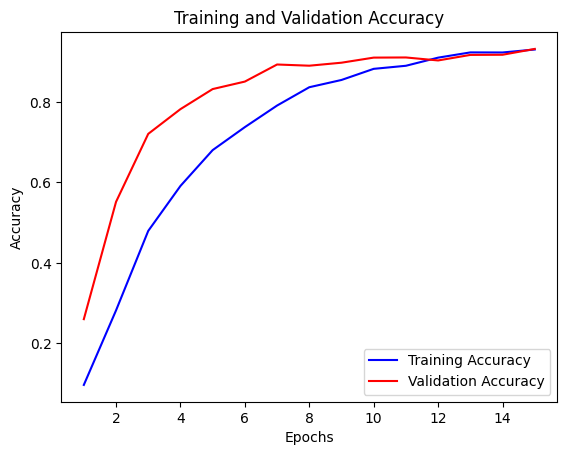

In [ ]:
# Train the model and store the training history
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=15, batch_size=32)

# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
# Make predictions on the test data
predictions = model.predict(x_test)

# Convert predictions to categorical format
predicted_labels = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(np.argmax(y_test, axis=1), predicted_labels)

# Print the predicted labels for the test images
predicted_labels = lb.inverse_transform(np.argmax(predictions, axis=1))
print("Predicted labels for test images:", predicted_labels)

# Print the accuracy
print("Accuracy:", accuracy)

105/105 [==============================] - 3s 24ms/step
Predicted labels for test images: ['zain' 'zah' 'jeem' ... 'sad' 'sheen' 'kaf']
Accuracy: 0.9339285714285714


# Changeing The Batch Size

In [ ]:
# Splitting the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Define the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=x_train[0].shape))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(28, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
#Print a summary of the model
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 6, 6, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_11 (Conv2D)          (None, 4, 4, 128)         73856     
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 2, 2, 128)        

Epoch 1/20
168/168 [==============================] - 21s 115ms/step - loss: 4.0005 - accuracy: 0.0608 - val_loss: 2.8605 - val_accuracy: 0.1574
Epoch 2/20
168/168 [==============================] - 16s 94ms/step - loss: 2.8894 - accuracy: 0.1215 - val_loss: 2.4168 - val_accuracy: 0.2199
Epoch 3/20
168/168 [==============================] - 17s 100ms/step - loss: 2.6672 - accuracy: 0.1667 - val_loss: 2.1280 - val_accuracy: 0.3039
Epoch 4/20
168/168 [==============================] - 16s 98ms/step - loss: 2.4068 - accuracy: 0.2308 - val_loss: 1.7827 - val_accuracy: 0.4059
Epoch 5/20
168/168 [==============================] - 17s 101ms/step - loss: 2.0839 - accuracy: 0.3022 - val_loss: 1.3746 - val_accuracy: 0.5435
Epoch 6/20
168/168 [==============================] - 18s 106ms/step - loss: 1.8209 - accuracy: 0.3610 - val_loss: 1.1293 - val_accuracy: 0.6231
Epoch 7/20
168/168 [==============================] - 17s 104ms/step - loss: 1.5272 - accuracy: 0.4591 - val_loss: 0.9122 - val_accu

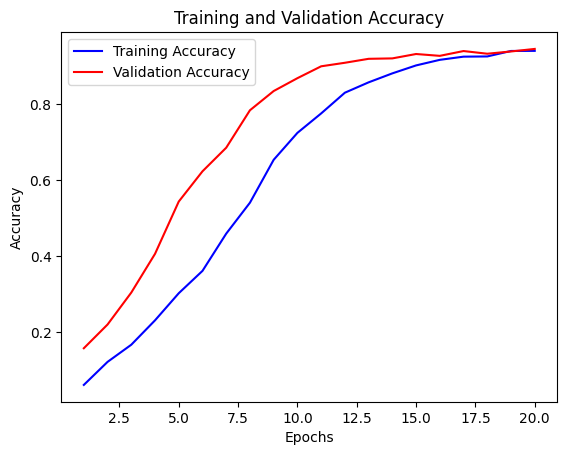

In [ ]:
# Train the model and store the training history
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=20, batch_size=64)

# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
# Make predictions on the test data
predictions = model.predict(x_test)

# Convert predictions to categorical format
predicted_labels = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(np.argmax(y_test, axis=1), predicted_labels)

# Print the predicted labels for the test images
predicted_labels = lb.inverse_transform(np.argmax(predictions, axis=1))
print("Predicted labels for test images:", predicted_labels)

# Print the accuracy
print("Accuracy:", accuracy)

105/105 [==============================] - 1s 13ms/step
Predicted labels for test images: ['zain' 'zah' 'jeem' ... 'sad' 'sheen' 'kaf']
Accuracy: 0.9434523809523809
